In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
np.random.seed(42)

# 1B

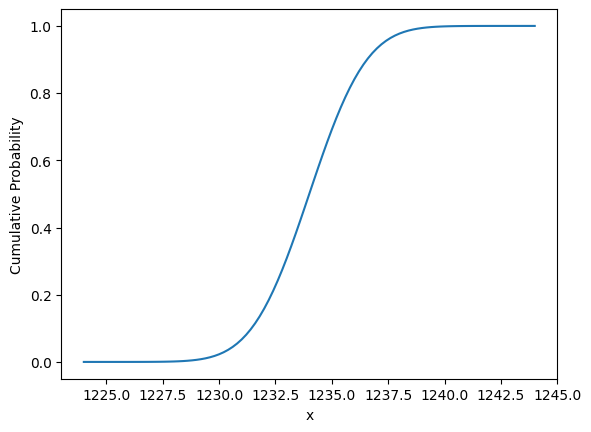

In [2]:
results=[]
mid=1234
std=2
sp=np.linspace(-5,5,101)
xlist=[mid+std*i for i in sp]
for x in xlist:
    result=stats.norm.cdf(x,loc=mid,scale=std)
    results.append(result)
fig,ax=plt.subplots(1,1)
ax.plot(xlist,results); #sigma vs cdf plot
ax.set_xlabel("x");
ax.set_ylabel("Cumulative Probability");

# 1C

In [3]:
print(f"The cdf at 1,2, and 5 sigma are: {results[60]:.3f}, {results[70]:.4f}, {results[100]:.7f}") #cdf at 1,2,5 sigma
print(f"The x at 1,2, and 5 sigma are: {xlist[60]:.0f}, {xlist[70]:.0f}, {xlist[100]:.0f}") #x at 1,2,5 sigma

The cdf at 1,2, and 5 sigma are: 0.841, 0.9772, 0.9999997
The x at 1,2, and 5 sigma are: 1236, 1238, 1244


In [4]:
print(stats.norm.ppf(0.841,loc=mid,scale=std)) #1 Sigma
print(stats.norm.ppf(0.9772,loc=mid,scale=std)) #2 Sigma
print(stats.norm.ppf(0.9999997,loc=mid,scale=std)) #5 Sigma

1235.9971525412313
1237.9981544299435
1243.9824342798759


The values from ppf is very close to the values from my initial values.

# 2B

In [5]:
gamma=stats.gamma.rvs(a=4,loc=mid,scale=std,size=100000)

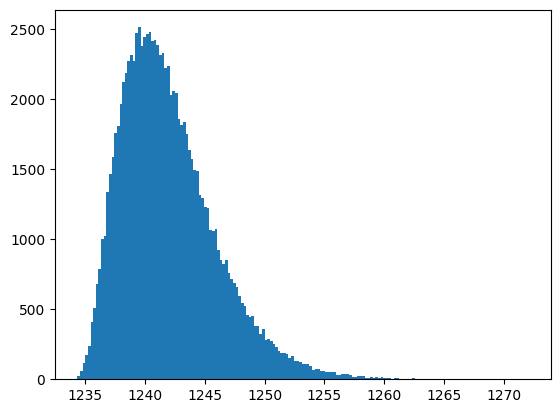

In [6]:
plt.hist(gamma,bins="fd");

# 3A
Let's pick the x value of the measurement to be 1254 (1234+20).

# 3B
What is the probability that the measurement is from the background (gamma distribution)?

# 3C
Since The measurement is on the right tail of the distribution, the integral should be from 1254 to $\infty$ \
But, CDF function integrates from 0 to 1254. So, we have to use 1-CDF since 1 equals to the integral from 0 to $\infty$
$$\int_{x=1254}^{\infty} P(x) dx = 1 - \int_{x=0}^{1254} P(x) dx$$

# 3D

In [7]:
measure=1250
CDF=1-stats.gamma.cdf(measure,a=4,loc=mid,scale=std)
print(f"{1-CDF:.6f}")

0.957620


So, around 4.2 percent the background can be this measurement

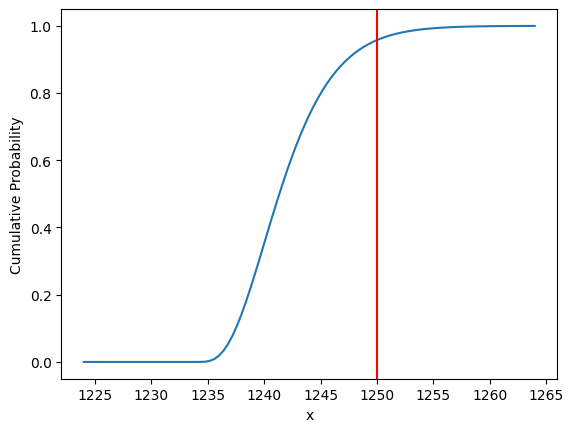

In [8]:
sp2=np.linspace(-5,15,101)
xlist=[mid+std*i for i in sp2]
reslist=[]
for x in xlist:
    res=stats.gamma.cdf(x,a=4,loc=mid,scale=std)
    reslist.append(res)
fig,ax=plt.subplots(1,1)
ax.plot(xlist,reslist); #sigma vs cdf plot
ax.set_xlabel("x");
ax.set_ylabel("Cumulative Probability");
ax.axvline(x=measure,color='r')

# 3E
Since 1250 is on the right side of the tail, CDF is going to be used for Gaussian PPF

In [9]:
sig=stats.norm.ppf(1-CDF)
print(f"The equivalent sigma is {sig:.3f}")

The equivalent sigma is 1.724


# 4

In [10]:
def sigfinder(x):
    return stats.norm.ppf(stats.gamma.cdf(x,a=4,loc=mid,scale=std))

In [11]:
print(sigfinder(1254))

2.3139201726832166


In [12]:
print(sigfinder(1236))

-2.075110295660974


In [13]:
print(sigfinder(1260))

3.0756277123069804
